# Exploratory Data Analysis

In [30]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("../data/faang_stock_prices.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by ticker and date
df = df.sort_values(["Ticker", "Date"])

In [36]:
# Basic dataset inspection
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(14964, 19)

Missing Values:
Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64

Duplicate Rows:
0


In [37]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             14964 non-null  datetime64[ns]
 1   Ticker           14964 non-null  object        
 2   Open             14964 non-null  float64       
 3   High             14964 non-null  float64       
 4   Low              14964 non-null  float64       
 5   Close            14964 non-null  float64       
 6   Volume           14964 non-null  int64         
 7   SMA_7            14964 non-null  float64       
 8   SMA_21           14964 non-null  float64       
 9   EMA_12           14964 non-null  float64       
 10  EMA_26           14964 non-null  float64       
 11  RSI_14           14964 non-null  float64       
 12  MACD             14964 non-null  float64       
 13  MACD_Signal      14964 non-null  float64       
 14  Bollinger_Upper  14964 non-n

In [32]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,Date,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
count,14964,14964.000000,14964.000000,14964.000000,14964.000000,1.496400e+04,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000
mean,2021-02-03 05:47:00.529270272,147.969959,149.643762,146.256716,147.999839,1.186247e+08,147.631588,146.746646,147.314335,146.428158,55.686976,0.886176,0.888239,156.048174,137.572513,0.001335,0.018537,148.126287
min,2016-02-23 00:00:00,0.762756,0.777392,0.746413,0.767738,4.726100e+06,0.710800,0.683503,0.704268,0.691066,3.180003,-33.155902,-30.727270,0.780719,0.569458,-0.263901,0.001171,0.767738
25%,2018-08-13 00:00:00,50.094322,50.468777,49.669161,50.083026,2.428050e+07,49.906533,49.334041,49.600781,49.146090,43.754097,-0.331123,-0.283075,51.982837,47.077112,-0.008375,0.010449,50.149251
50%,2021-02-03 12:00:00,123.841343,125.102966,122.262753,123.922924,4.432600e+07,123.301276,122.667958,123.067546,122.222704,56.381405,0.507975,0.491224,131.496224,114.337861,0.001286,0.015466,124.013718
75%,2023-07-28 00:00:00,189.299623,191.429458,186.986899,189.079613,1.057329e+08,188.811102,187.325549,187.740894,186.739774,67.819077,2.160937,2.068120,199.721259,176.264492,0.011626,0.022748,189.254452
max,2026-01-22 00:00:00,789.972167,795.064526,779.657506,788.823792,3.692928e+09,775.982954,762.484980,766.193137,757.613109,100.000000,29.441884,26.790650,813.954233,734.580075,0.298067,0.120255,788.823792
std,NaN,132.599874,134.001750,131.065146,132.547711,1.889461e+08,132.261571,131.557653,131.956650,131.170115,16.597436,4.177106,3.932864,139.825874,123.751294,0.022069,0.012431,132.632577


In [33]:
print("\nDate Range:")
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())


Date Range:
Start Date: 2016-02-23 00:00:00
End Date: 2026-01-22 00:00:00


In [35]:
print("\nAvailable Stocks:")
print(df["Ticker"].unique())


Available Stocks:
['AAPL' 'AMZN' 'GOOGL' 'META' 'MSFT' 'NVDA']


# Visualizations

In [40]:
# Create daily returns
df["Daily_Return"] = (
    df.groupby("Ticker")["Close"].pct_change()
)

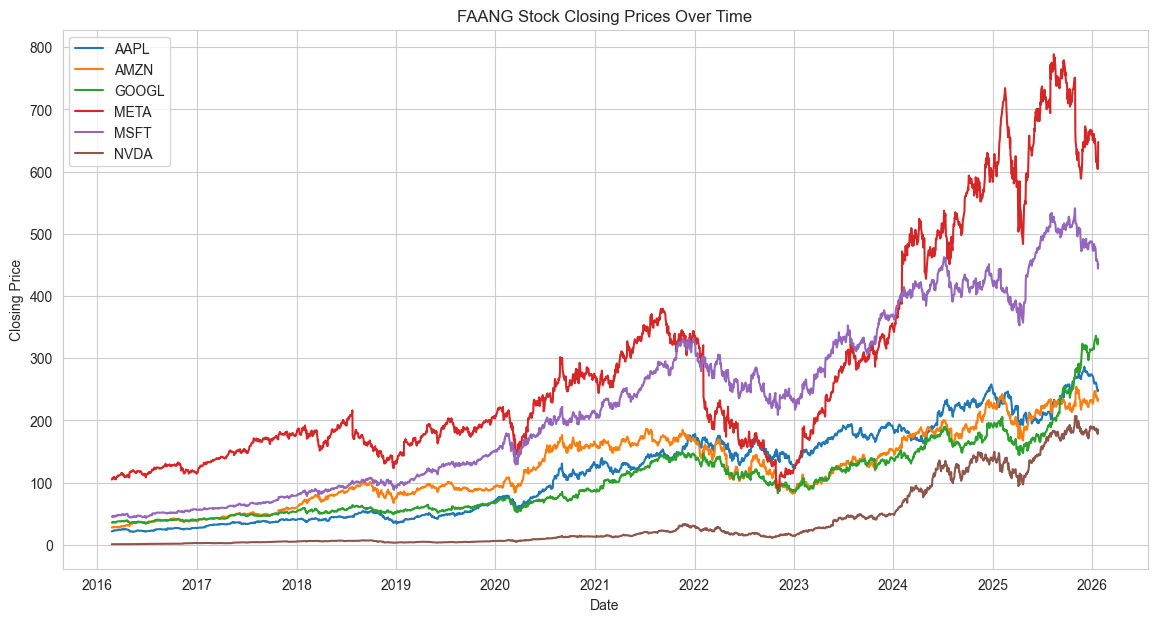

In [41]:
# Closing price comparison
plt.figure(figsize=(14,7))

for ticker in df["Ticker"].unique():

    company_df = df[df["Ticker"] == ticker]

    plt.plot(
        company_df["Date"],
        company_df["Close"],
        label=ticker
    )

plt.title("FAANG Stock Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

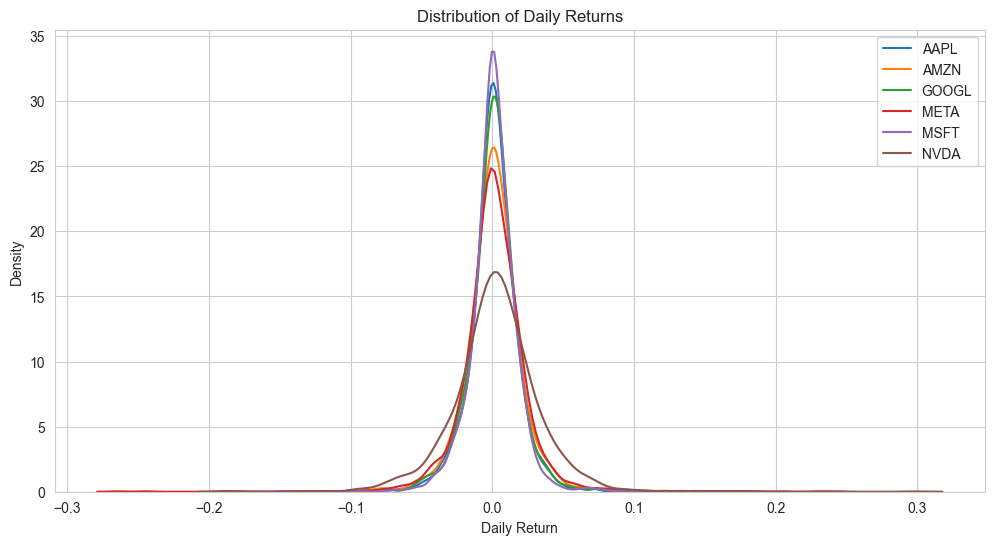

In [42]:
# Distribution of daily returns
plt.figure(figsize=(12,6))

for ticker in df["Ticker"].unique():

    company_df = df[df["Ticker"] == ticker]

    sns.kdeplot(
        company_df["Daily_Return"].dropna(),
        label=ticker
    )

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.legend()

plt.show()


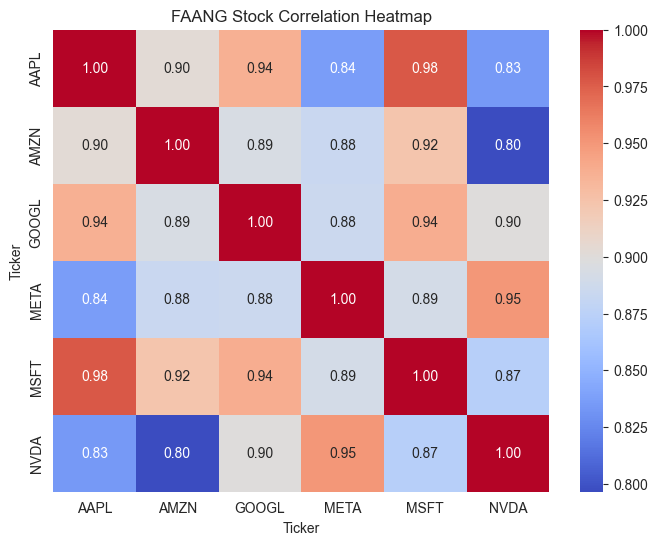

In [43]:
# Correlation between stock prices
pivot_df = df.pivot(
    index="Date",
    columns="Ticker",
    values="Close"
)

corr_matrix = pivot_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("FAANG Stock Correlation Heatmap")

plt.show()


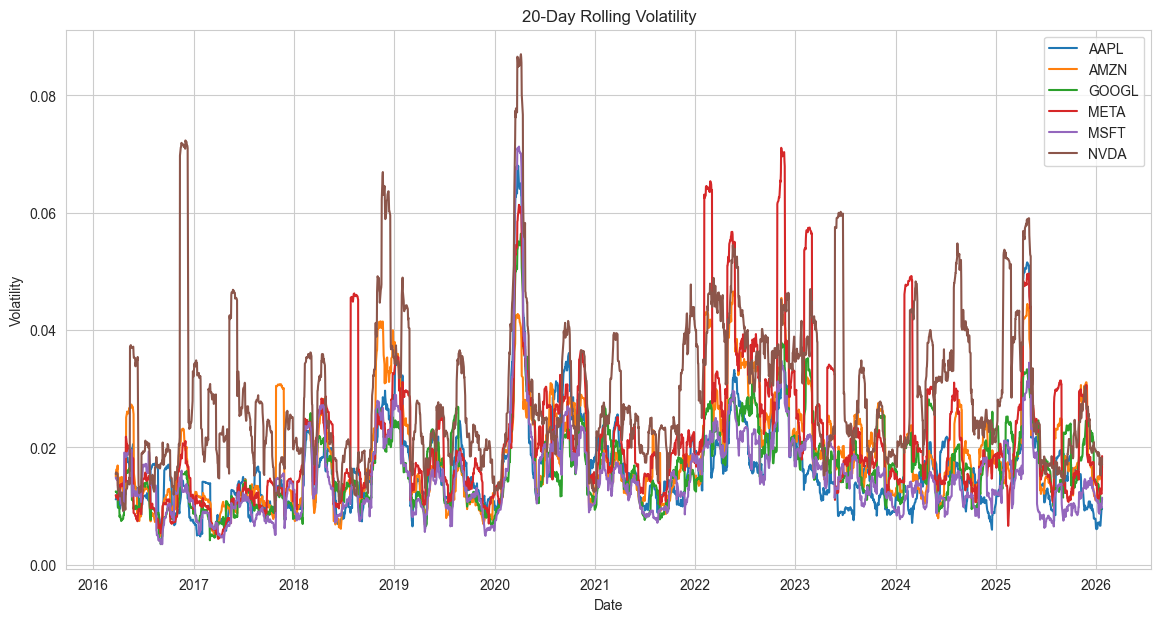

In [44]:
# 20-day rolling volatility
plt.figure(figsize=(14,7))

for ticker in df["Ticker"].unique():

    company_df = df[df["Ticker"] == ticker].copy()

    company_df["Volatility_20"] = (
        company_df["Daily_Return"]
        .rolling(window=20)
        .std()
    )

    plt.plot(
        company_df["Date"],
        company_df["Volatility_20"],
        label=ticker
    )

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()

plt.show()


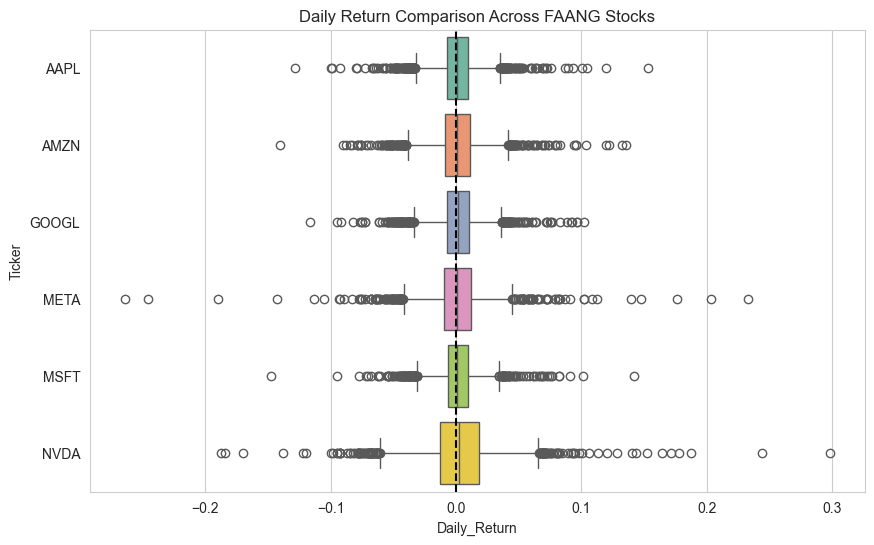

In [45]:
# Boxplot of daily returns
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Daily_Return",
    y="Ticker",
    hue="Ticker",
    palette="Set2"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Daily Return Comparison Across FAANG Stocks")

# Hide duplicate legend
plt.legend([], [], frameon=False)

plt.show()